In [5]:
def get_top_keywords(url: str, k: int = 10, return_details: bool = False):
    import re
    import urllib.request
    from urllib.parse import urlparse
    from collections import Counter
    from bs4 import BeautifulSoup, Comment
    from nltk.corpus import stopwords
    from nltk import wordpunct_tokenize
    import nltk
    
    import requests

    # --------------------- ensure NLTK data ---------------------
    try:
        stopwords.words("english")
    except LookupError:
        nltk.download("stopwords")

    # --------------------- config ---------------------
    COMMON_NOISE_WORDS = set("""
    January debt est dec big than who use jun jan feb mar apr may jul august dec oct nov sep dec
    product continue one two three four five please thanks find helpful week job experience women girl
    apology read show eve knowledge benefit appointment street way staff salon discount gift cost thing
    world close party love letters rewards offers special close pack wed dollars voucher gifts vouchers
    welcome therefore march nights need name please show sisters thank menu today always time needs
    welcome march february april may june jully august september october november december day year
    month minute second seconds
    """.split())

    SPECIAL_CHARS_RE = re.compile(r"[^ \.\,\|\@#\$\%\^\&\*\(\)\_\+\=\-\[\]\{\}\;\:\'\"\\\<\>\?\/\.\,\-]")

    # --------------------- helpers ---------------------
    def _is_visible_text(element) -> bool:
        if element.parent.name in ["html", "style", "script", "head", "[document]", "img"]:
            return False
        if isinstance(element, Comment):
            return False
        return True

    def _extract_visible_text_from_html(html: bytes) -> str:
        soup = BeautifulSoup(html, "lxml")
        texts = soup.find_all(string=True)
        visible_texts = filter(_is_visible_text, texts)
        return " ".join(t.strip() for t in visible_texts)

    def _normalize_whitespace(text: str) -> str:
        lines = (line.strip() for line in text.splitlines())
        chunks = (phrase.strip() for line in lines for phrase in line.split("  "))
        return "\n".join(chunk for chunk in chunks if chunk)

    def _fetch_page(u: str):
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
        }
        response = requests.get(u, headers=headers, timeout=20)
        response.raise_for_status()
        html = response.content
        soup = BeautifulSoup(html, "lxml")
        raw_text = _extract_visible_text_from_html(html)
        clean_text = _normalize_whitespace(raw_text)
        return clean_text, soup

    def _calculate_language_scores(text: str) -> dict:
        ratios = {}
        tokens = wordpunct_tokenize(text)
        words = [w.lower() for w in tokens]
        words_set = set(words)

        for lang in stopwords.fileids():
            try:
                stop_set = set(stopwords.words(lang))
            except Exception:
                continue
            common = words_set.intersection(stop_set)
            ratios[lang] = len(common)
        return ratios

    def _detect_language_and_stopwords(text: str):
        ratios = _calculate_language_scores(text)
        if not ratios:
            # fallback to English
            return "english", set(stopwords.words("english"))

        detected_lang = max(ratios, key=ratios.get)

        # some nltk ids (like 'porter') are not stopword sets; fall back to english if needed
        try:
            sw = set(stopwords.words(detected_lang))
        except Exception:
            detected_lang, sw = "english", set(stopwords.words("english"))
        return detected_lang, sw

    def _clean_text_to_words(text: str, stopword_list: set) -> list:
        words = []
        LETTERS_ONLY_RE = re.compile(r"[^a-zA-ZåäöÅÄÖ]+")

        for raw_word in text.split():
            token = LETTERS_ONLY_RE.sub("", raw_word).lower()

            if (
                len(token) > 1
                and not token[0].isdigit()
                and token not in stopword_list
                and token not in COMMON_NOISE_WORDS
                and not token.isdigit()
            ):
                words.append(token)

        return words

    def _split_url_host(u: str) -> list:
        parsed = urlparse(u)
        host = parsed.hostname or ""
        parts = []
        for chunk in host.split("."):
            chunk = chunk.lower()
            if chunk not in ["", "https", "www", "com", "-", "php", "pk", "fi", "http"]:
                parts.append(chunk)
        return parts

    def _split_url_path_and_query(u: str, host_parts: list) -> list:
        path_tokens = []
        for segment in u.split("/"):
            for dot_part in segment.split("."):
                for dash_part in dot_part.split("-"):
                    token = dash_part.lower()
                    if (
                        token
                        and token not in [
                            "https", "www", "com", "-", "php", "pk", "fi",
                            "https:", "http", "http:", "http:",
                        ]
                        and token not in host_parts
                    ):
                        path_tokens.append(token)
        return path_tokens

    def _extract_tag_texts(soup, tag_name: str) -> list:
        out = []
        for el in soup.find_all(tag_name):
            t = el.get_text(strip=True).lower()
            if t:
                out.append(t)
        return out

    def _explode_texts_to_words(text_list: list) -> list:
        out = []
        for text in text_list:
            for comma_chunk in text.split(","):
                for w in comma_chunk.split():
                    out.append(w)
        return out

    def _extract_headers_anchors_title_words(soup):
        h1 = _explode_texts_to_words(_extract_tag_texts(soup, "h1"))
        h2 = _explode_texts_to_words(_extract_tag_texts(soup, "h2"))
        h3 = _explode_texts_to_words(_extract_tag_texts(soup, "h3"))
        h4 = _explode_texts_to_words(_extract_tag_texts(soup, "h4"))
        h5 = _explode_texts_to_words(_extract_tag_texts(soup, "h5"))
        h6 = _explode_texts_to_words(_extract_tag_texts(soup, "h6"))
        a = _explode_texts_to_words(_extract_tag_texts(soup, "a"))
        ti = _explode_texts_to_words(_extract_tag_texts(soup, "title"))
        return h1, h2, h3, h4, h5, h6, a, ti

    def _tf_score(freq: int, total_tokens: int) -> float:
        # Keep your original behavior
        if total_tokens < 50:
            return (freq / 100.0) * 50
        else:
            return (freq / 100.0) * 20

    def _compute_keyword_scores(words: list, soup, u: str) -> dict:
        freq = Counter(words)
        total_tokens = len(words)

        h1, h2, h3, h4, h5, h6, anchor, title = _extract_headers_anchors_title_words(soup)
        url_host = _split_url_host(u)
        url_path = _split_url_path_and_query(u, url_host)

        headers_names = ["H1", "H2", "H3", "H4", "H5", "H6", "A", "Title", "URL-H", "URL-Q"]
        headers_scores = [6, 5, 4, 3, 2, 2, 1, 5, 5, 4]
        headers_lists = [h1, h2, h3, h4, h5, h6, anchor, title, url_host, url_path]

        word_info = {}  # word -> (freq, [tags], final_score)
        for w, c in freq.items():
            base = _tf_score(c, total_tokens)
            tag_boost, tag_names = 0.0, []
            for idx, toks in enumerate(headers_lists):
                if w in toks:
                    tag_boost += headers_scores[idx]
                    tag_names.append(headers_names[idx])
            word_info[w] = (c, tag_names, base + tag_boost)

        return word_info

    # --------------------- pipeline ---------------------
    clean_text, soup = _fetch_page(url)
    _, stopword_list = _detect_language_and_stopwords(clean_text)
    tokens = _clean_text_to_words(clean_text, stopword_list)

    if not tokens:
        return [] if not return_details else []

    keyword_data = _compute_keyword_scores(tokens, soup, url)
    top = sorted(keyword_data.items(), key=lambda kv: kv[1][2], reverse=True)[:k]

    if return_details:
        # [(word, freq, score, tags), ...]
        return [(w, meta[0], meta[2], meta[1]) for w, meta in top]
    else:
        # [word, ...]
        return [w for w, _ in top]

In [6]:

# --------------------- evaluation (Herald) ---------------------

import urllib.request
import matplotlib.pyplot as plt
import numpy as np

BASE = "https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/indianexpress" 
# "https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/herald"


def Get_Prc_Rcl_Fscr_input_GT_and_Keywords_List(ground_truth, keywords):
    matches = [(word, ground_truth.count(word)) for word in ground_truth if word in keywords]

    ground_truth_count = len(ground_truth)
    keywords_count = len(keywords)
    match_count = len(matches)

    if ground_truth_count == 0 or keywords_count == 0:
        return (0, 0, 0)

    precision = match_count / keywords_count
    recall = match_count / ground_truth_count

    if precision + recall == 0:
        return (0, 0, 0)

    f_score = (2 * precision * recall) / (precision + recall)
    return (precision, recall, f_score)


def Make_score_round_and_divide(precision_sum, recall_sum, fscore_sum, total_webpages):
    avg_precision = round(precision_sum / total_webpages, 2)
    avg_recall = round(recall_sum / total_webpages, 2)
    avg_fscore = round(fscore_sum / total_webpages, 2)
    return (avg_precision, avg_recall, avg_fscore)


def read_url(url):
    with urllib.request.urlopen(url) as f:
        return f.read().decode("utf-8-sig").strip()


def load_herald_case(index):
    base = f"{BASE}/{index}"
    url_text = read_url(f"{base}/URL.txt")
    gt_text = read_url(f"{base}/GT.txt")
    gt_tokens = gt_text.lower().split()
    return url_text, gt_tokens


def Score_evaluation(total_webpages):
    precision_sum = 0.0
    recall_sum = 0.0
    fscore_sum = 0.0
    
    # Store metrics for each webpage
    webpage_ids = []
    precisions = []
    recalls = []
    fscores = []

    for i in range(total_webpages):
        URL, gt_keywords = load_herald_case(str(i))
        drank_keywords = get_top_keywords(URL)                
        p, r, f = Get_Prc_Rcl_Fscr_input_GT_and_Keywords_List(gt_keywords, drank_keywords)
        print(f"Webpage {i}: GT={len(gt_keywords)}, Extracted={len(drank_keywords)}, P={p:.2f}, R={r:.2f}, F={f:.2f}")
        
        # Store for graphing
        webpage_ids.append(i)
        precisions.append(p)
        recalls.append(r)
        fscores.append(f)
        
        precision_sum += p
        recall_sum += r
        fscore_sum += f

    return precision_sum, recall_sum, fscore_sum, webpage_ids, precisions, recalls, fscores

total_webpages = 100
precision_sum, recall_sum, fscore_sum, webpage_ids, precisions, recalls, fscores = Score_evaluation(total_webpages)

avg_p, avg_r, avg_f = Make_score_round_and_divide(
    precision_sum, recall_sum, fscore_sum, total_webpages
)

print("=== AVERAGE OVER ALL WEBPAGES ===")
print("Average Precision:", avg_p)
print("Average Recall   :", avg_r)
print("Average F-score  :", avg_f)


Webpage 0: GT=5, Extracted=10, P=0.40, R=0.80, F=0.53
Webpage 1: GT=7, Extracted=10, P=0.10, R=0.14, F=0.12
Webpage 2: GT=5, Extracted=10, P=0.10, R=0.20, F=0.13
Webpage 3: GT=5, Extracted=10, P=0.40, R=0.80, F=0.53
Webpage 4: GT=11, Extracted=10, P=0.40, R=0.36, F=0.38
Webpage 5: GT=6, Extracted=10, P=0.60, R=1.00, F=0.75
Webpage 6: GT=4, Extracted=10, P=0.10, R=0.25, F=0.14
Webpage 7: GT=9, Extracted=10, P=0.20, R=0.22, F=0.21
Webpage 8: GT=5, Extracted=10, P=0.20, R=0.40, F=0.27
Webpage 9: GT=7, Extracted=10, P=0.50, R=0.71, F=0.59
Webpage 10: GT=7, Extracted=10, P=0.20, R=0.29, F=0.24
Webpage 11: GT=7, Extracted=10, P=0.30, R=0.43, F=0.35
Webpage 12: GT=9, Extracted=10, P=0.30, R=0.33, F=0.32
Webpage 13: GT=6, Extracted=10, P=0.50, R=0.83, F=0.62
Webpage 14: GT=5, Extracted=10, P=0.20, R=0.40, F=0.27
Webpage 15: GT=7, Extracted=10, P=0.10, R=0.14, F=0.12
Webpage 16: GT=5, Extracted=10, P=0.40, R=0.80, F=0.53
Webpage 17: GT=8, Extracted=10, P=0.10, R=0.12, F=0.11
Webpage 18: GT=8, E

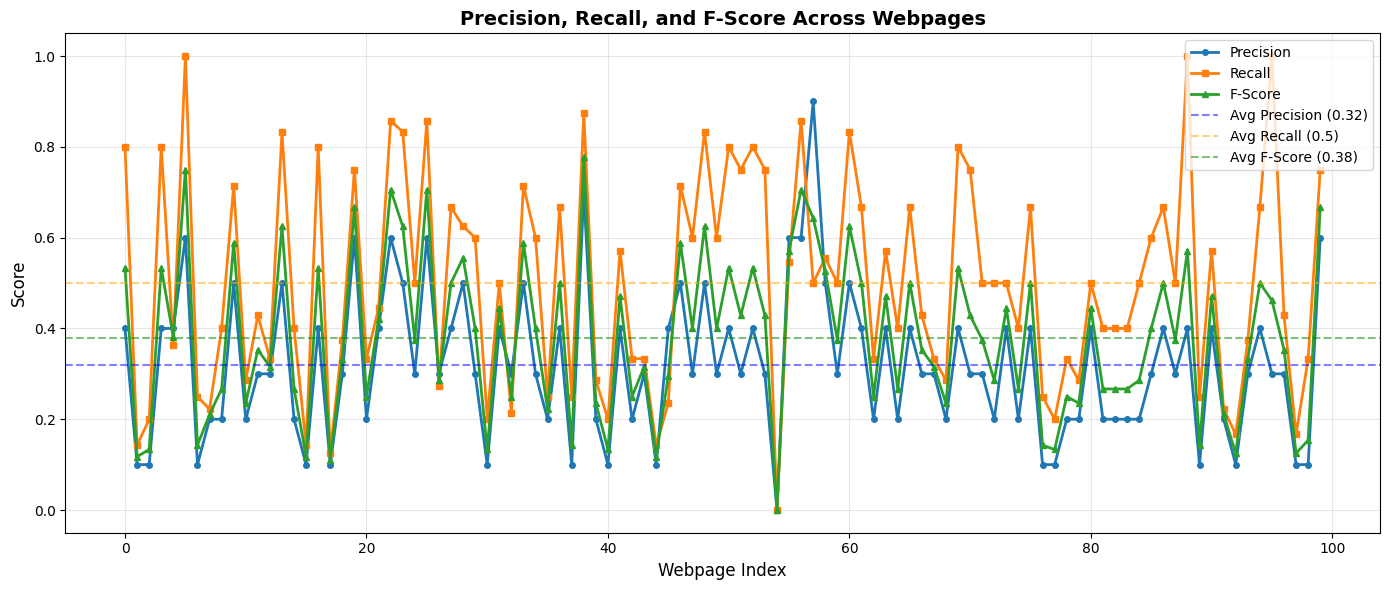

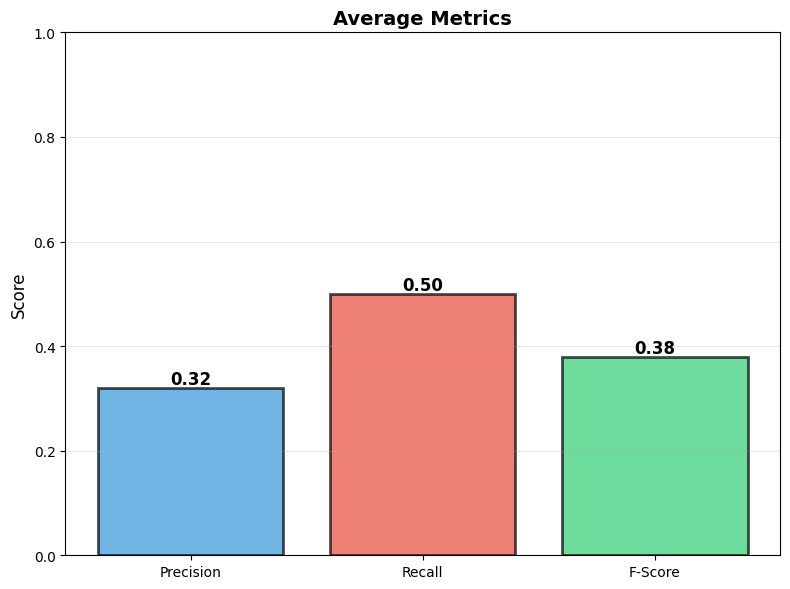

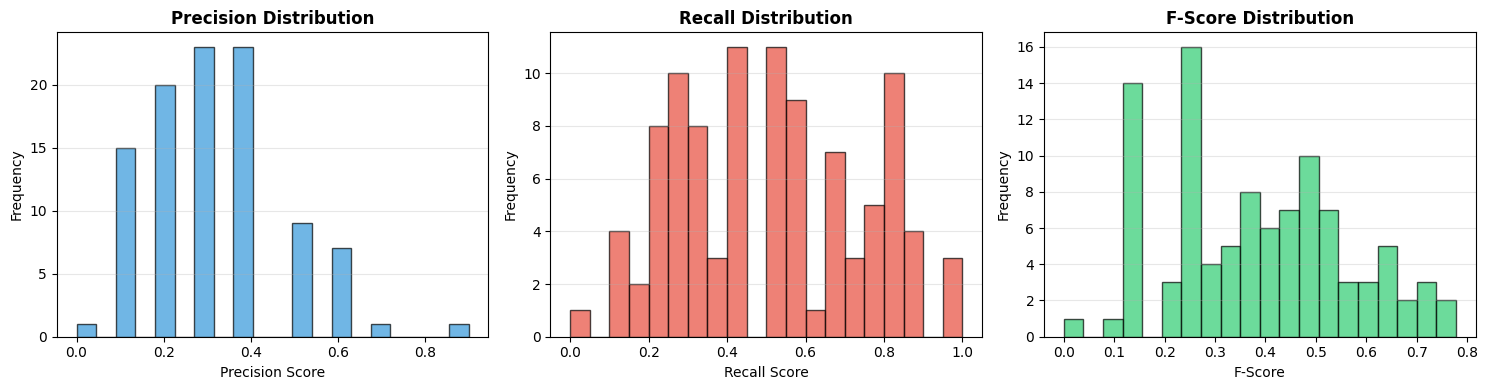

In [7]:
# --------------------- Visualization ---------------------

# Plot 1: Line chart of P, R, F-score across webpages
plt.figure(figsize=(14, 6))
plt.plot(webpage_ids, precisions, marker='o', label='Precision', linewidth=2, markersize=4)
plt.plot(webpage_ids, recalls, marker='s', label='Recall', linewidth=2, markersize=4)
plt.plot(webpage_ids, fscores, marker='^', label='F-Score', linewidth=2, markersize=4)

plt.axhline(y=avg_p, color='blue', linestyle='--', alpha=0.5, label=f'Avg Precision ({avg_p})')
plt.axhline(y=avg_r, color='orange', linestyle='--', alpha=0.5, label=f'Avg Recall ({avg_r})')
plt.axhline(y=avg_f, color='green', linestyle='--', alpha=0.5, label=f'Avg F-Score ({avg_f})')

plt.xlabel('Webpage Index', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision, Recall, and F-Score Across Webpages', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Bar chart of averages
fig, ax = plt.subplots(figsize=(8, 6))
metrics = ['Precision', 'Recall', 'F-Score']
values = [avg_p, avg_r, avg_f]
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars = ax.bar(metrics, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Average Metrics', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Plot 3: Distribution histogram
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(precisions, bins=20, color='#3498db', alpha=0.7, edgecolor='black')
axes[0].set_title('Precision Distribution', fontweight='bold')
axes[0].set_xlabel('Precision Score')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].hist(recalls, bins=20, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].set_title('Recall Distribution', fontweight='bold')
axes[1].set_xlabel('Recall Score')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].hist(fscores, bins=20, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[2].set_title('F-Score Distribution', fontweight='bold')
axes[2].set_xlabel('F-Score')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
